This notebook demonstrates a simple linear regression analysis using Python to model Salary based on Years of Experience.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
dataset = pd.read_csv("../regression_data.csv")

Could not save font_manager cache Lock error: Matplotlib failed to acquire the following lock file:
    /users/PAS3421/teichmann22/.cache/matplotlib/fontlist-v3.11.0.json.matplotlib-lock
This maybe due to another process holding this lock file.  If you are sure no
other Matplotlib process is running, remove this file and try again.


In [2]:
dataset

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.7,57189.0
9,4.0,63218.0


In [3]:
x = dataset['YearsExperience']
x

0    1.1
1    1.3
2    1.5
3    2.0
4    2.2
5    2.9
6    3.0
7    3.2
8    3.7
9    4.0
Name: YearsExperience, dtype: float64

In [4]:
y = dataset['Salary']
y

0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
5    56642.0
6    60150.0
7    54445.0
8    57189.0
9    63218.0
Name: Salary, dtype: float64

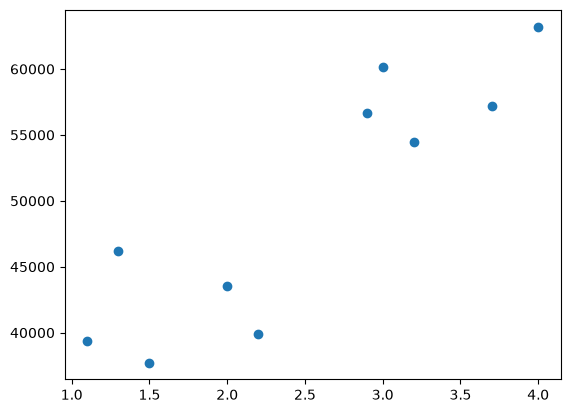

In [5]:
plt.scatter(x,y)

In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(dataset[["YearsExperience"]], dataset[["Salary"]])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[8285.29]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[29203.52]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [7]:
print('R-squared value')
model.score(dataset[["YearsExperience"]], dataset[["Salary"]])  # R-squared

R-squared value


0.7851515863136573

In [8]:
from scipy.stats import linregress

In [9]:
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(slope)
y_pred = slope * x + intercept

8285.292099903527


In [10]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y, y_pred)
print(mse)

17523844.08290278


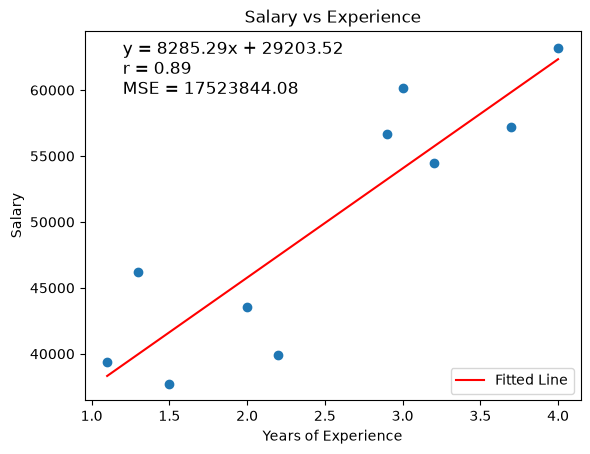

In [11]:
plt.scatter(x, y)
plt.plot(x, y_pred, 'r-', label='Fitted Line')
plt.text(1.2, max(y) - 3500,
         f"y = {slope:.2f}x + {intercept:.2f}\n"
         f"r = {r_value:.2f}\n MSE = {mse:.2f}",
         fontsize=12)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.legend()
plt.savefig("regression_plot_python.png")
plt.show()